# Red Neuronal Convolucional para Reconocimiento de Expresiones Faciales (FER-2013)

**Maestría en Inteligencia Artificial Aplicada — UIDE**
**Asignatura:** Aprendizaje Profundo (59003) — MIA-B
**Semana 2 — Práctica Grupal**
**Grupo 5**

---

## Resumen del trabajo

Este notebook implementa una **Red Neuronal Convolucional (CNN)** usando Keras/TensorFlow sobre el dataset **FER-2013** (Facial Expression Recognition 2013), con el objetivo de clasificar imágenes faciales de 48×48 píxeles en escala de grises en una de **siete expresiones emocionales**: enojo, asco, miedo, felicidad, tristeza, sorpresa y neutral.

El experimento principal compara **tres variantes incrementales** de la misma arquitectura — Baseline, Regularizada y Aumentada — para aislar el efecto de la regularización (BatchNorm + Dropout + `class_weight`) y de la aumentación de datos (RandomFlip / RandomRotation / RandomZoom) sobre la generalización y el manejo del fuerte desbalance de clases del dataset.

### Motivación profesional

La detección de expresiones faciales tiene aplicación directa en plataformas de psicoeducación, monitoreo de bienestar emocional asistido por IA y validación de intervenciones psicológicas. Como continuación natural de la Semana 1 (predicción de búsqueda de tratamiento sobre datos tabulares), esta semana avanzamos de las *características declaradas* en una encuesta a las **características visuales que el modelo aprende por sí mismo** a partir de la imagen — un cambio cualitativo que también responde directamente al feedback recibido por el docente.

**Importante:** las expresiones faciales son una proxy imperfecta del estado emocional real. Este modelo no diagnostica emociones; clasifica patrones visuales en imágenes. Cualquier uso aplicado requiere validación clínica adicional.


---

## 📋 Comentarios del docente sobre esta entrega (40/40)

> *Sección requerida por el informe final individual del cuatrimestre — comentarios del Prof. J. Rodríguez Chivata recibidos sobre esta práctica.*

**Comentario del docente:**

> *"Hola Grupo 5, felicitaciones la práctica ha estado muy bien desarrollada y explicada. Cubre todos los puntos solicitados y el contenido es coherente con el código presentado.*
>
> *En cuanto a mis sugerencias. Ha sido una estrategia adecuada incrementar o cambiar el modelo basado en hipótesis de manera progresiva, así se ven comportamientos interesantes de una manera más fácil. Yo quitaría de la red las capas de MaxPooling basado en que la imagen es 48x48x1 (poca información) no quisiera quitar características con las dos capas de pooling, el objetivo principal del pooling es reducir computación pero aquí quizás esté quitando características importantes. Yo probaría algo así.*
>
> *El otro tema que veo es el desbalance, que class weight no haya aportado ni el aumento de datos es interesante, esta semana podrían expandir más la exploración con fine tuning y redes más grandes con regularización adecuada para ver el comportamiento.*
>
> *Por lo demás muy bien hecho."*

**Dos sugerencias accionables identificadas:**
1. **"Quitaría las capas de MaxPooling porque la imagen es 48×48×1 (poca información)"** → aplicado en Semana 3 (MobileNetV2 no usa MaxPooling por diseño — usa `Conv2D(stride=2)`).
2. **"Expandir con fine-tuning y redes más grandes con regularización adecuada"** → aplicado en Semana 3 (backbone de 88 capas + estrategia 2 fases con LR diferenciado 1000×).

La respuesta detallada se encuentra al final del notebook en la **§14 — Cierre del feedback profesoral**.

---


## 1. Aplicación del feedback de la Semana 1

En la entrega anterior recibimos dos observaciones puntuales del docente que estructuran las decisiones técnicas de esta semana:

### Feedback 1 — *"Trabajar más del lado de las características; One-Hot Encoding no es la solución"*

En la Semana 1 las variables categóricas se llevaron a OHE de forma directa, lo cual produjo un espacio de features ancho y poco estructurado. En esta semana el cambio es **cualitativo**, no incremental:

- **No hay ingeniería de features manual.** La CNN aprende su propia jerarquía de representaciones — bordes orientados en las primeras capas, texturas y partes de cara en capas intermedias, configuraciones de expresión en las capas profundas. Esto materializa la idea del docente: las características son el objeto principal del aprendizaje, no un pre-procesamiento secundario.
- **Las etiquetas se mantienen como enteros (sparse) en lugar de OHE de 7 dimensiones.** Usamos `sparse_categorical_crossentropy` en lugar de `categorical_crossentropy`. El feedback se aplica incluso al lado de los labels: solo se one-hot codifica cuando es estrictamente necesario.
- **Mostraremos la cara promedio por clase como diagnóstico visual** de qué "features pre-existentes" el modelo deberá aprender a discriminar — un EDA visual equivalente al EDA tabular de la semana pasada.

### Feedback 2 — *"Iniciar con un modelo menos complejo e ir analizando comportamientos"*

La Sección 7 está diseñada exactamente con esa filosofía. En lugar de presentar una única CNN profunda, se entrenan **tres variantes incrementales** en el siguiente orden:

| # | Variante | Cambios respecto a la anterior | Qué pretende diagnosticar |
|---|---|---|---|
| A | Baseline | Arquitectura mínima sin regularización ni aumentación | ¿Cuánto overfitting aparece sin defensas? ¿El modelo aprende o colapsa a la mayoría? |
| B | Regularizada | + BatchNorm tras cada Conv + Dropout moderado (0,20 conv / 0,30 dense) | ¿Cuánto cierra la brecha train/val la regularización bien calibrada? |
| C | Aumentada | + Aumentación (Flip / Rotation / Zoom) | ¿La aumentación añade valor más allá de la regularización? |

Cada paso se evalúa **antes** de añadir el siguiente, lo que hace el experimento auditable y permite atribuir cada mejora a una decisión específica.

> **Nota sobre `class_weight`:** una primera ejecución usaba `class_weight='balanced'` en B y C para mitigar el desbalance Happy:Disgust 16:1. La combinación con BatchNorm produjo gradientes iniciales muy inestables (pérdida ≈25 en la primera época) y los modelos terminaron en underfitting (variante C: train_acc 0,35). Se optó por **no usar `class_weight`** y dejar a la métrica F1-macro como salvaguarda contra modelos que ignoren clases minoritarias. Este hallazgo, que también apareció en Semana 1 con L2 λ=0,01, confirma que los hiperparámetros de regularización deben calibrarse al problema, no asumirse.

## 2. Configuración del entorno y carga de librerías

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

# Estilo de gráficos (coherente con el notebook de Semana 1)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')


TensorFlow: 2.16.2
Keras:      3.14.1


In [2]:
# Detección de aceleración por hardware
# En Apple Silicon (M1/M2/M3) con tensorflow-metal instalado, la GPU aparece como dispositivo
# tipo 'GPU' y Keras la usa automáticamente a través de Metal Performance Shaders.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU(s) detectada(s): {len(gpus)}')
    for g in gpus:
        print(f'  → {g.name} ({g.device_type})')
    print('\nKeras usará Metal Performance Shaders automáticamente.')
else:
    print('Sin GPU detectada — se usará CPU. El entrenamiento será notablemente más lento.')


GPU(s) detectada(s): 1
  → /physical_device:GPU:0 (GPU)

Keras usará Metal Performance Shaders automáticamente.


## 3. Dataset — FER-2013

**Fuente:** [FER-2013 (Facial Expression Recognition 2013)](https://www.kaggle.com/datasets/msambare/fer2013) — Kaggle.
**Origen original:** ICML 2013 Workshop on Representation Learning (Goodfellow et al., 2013).
**Total de imágenes:** 35.887 — 28.709 train / 7.178 test.
**Formato:** 48×48 píxeles, escala de grises, una cara centrada por imagen.
**Clases (7):** `angry`, `disgust`, `fear`, `happy`, `neutral`, `sad`, `surprise`.

### Justificación de la elección

FER-2013 es un dataset clásico para validar arquitecturas convolucionales por cuatro razones:

1. **Resolución baja (48×48)** → permite entrenar CNN desde cero en hardware modesto (incluyendo el M1 Max usado en este experimento) sin necesidad de transfer learning, que se reserva para la Semana 3.
2. **Escala de grises** → simplifica el canal de entrada y aísla el aprendizaje a la *forma* y *textura* facial, sin la confusión añadida del color.
3. **Desbalance fuerte y bien documentado** entre `happy` (mayoría) y `disgust` (minoría) — terreno fértil para discutir `class_weight` y métricas por clase, en línea con la asignatura.
4. **Tarea relevante** para la línea de trabajo de la entrega previa (psicología aplicada con IA) sin requerir datos protegidos.

### Estructura en disco

```
semana-2/data/
├── train/   (7 carpetas — 28.709 imágenes)
│   ├── angry/    disgust/   fear/    happy/
│   └── neutral/  sad/       surprise/
└── test/    (7 carpetas — 7.178 imágenes)
```


## 4. Análisis exploratorio de datos (EDA)

Antes de modelar, caracterizamos el dataset por **tres dimensiones**:

1. **Distribución de clases** → ¿hay desbalance? ¿de qué magnitud?
2. **Muestras visuales** → ¿cómo se ven los datos crudos?
3. **Cara promedio por clase** → ¿hay separabilidad visual entre clases? Es un pre-diagnóstico de qué tan fácil será la tarea para una CNN.


In [3]:
DATA_DIR  = Path('data')
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR  = DATA_DIR / 'test'

def class_counts(folder: Path) -> pd.Series:
    counts = {d.name: sum(1 for _ in d.iterdir())
              for d in sorted(folder.iterdir()) if d.is_dir()}
    return pd.Series(counts).sort_values(ascending=False)

train_counts = class_counts(TRAIN_DIR)
test_counts  = class_counts(TEST_DIR)

df_counts = pd.DataFrame({'Train': train_counts, 'Test': test_counts})
df_counts.loc['TOTAL'] = df_counts.sum()
df_counts['% Train'] = (df_counts['Train'] / df_counts.loc['TOTAL', 'Train'] * 100).round(2)
df_counts


,Train,Test,% Train
angry,3995,958,13.92
disgust,436,111,1.52
fear,4097,1024,14.27
happy,7215,1774,25.13
neutral,4965,1233,17.29
sad,4830,1247,16.82
surprise,3171,831,11.05
TOTAL,28709,7178,100.00


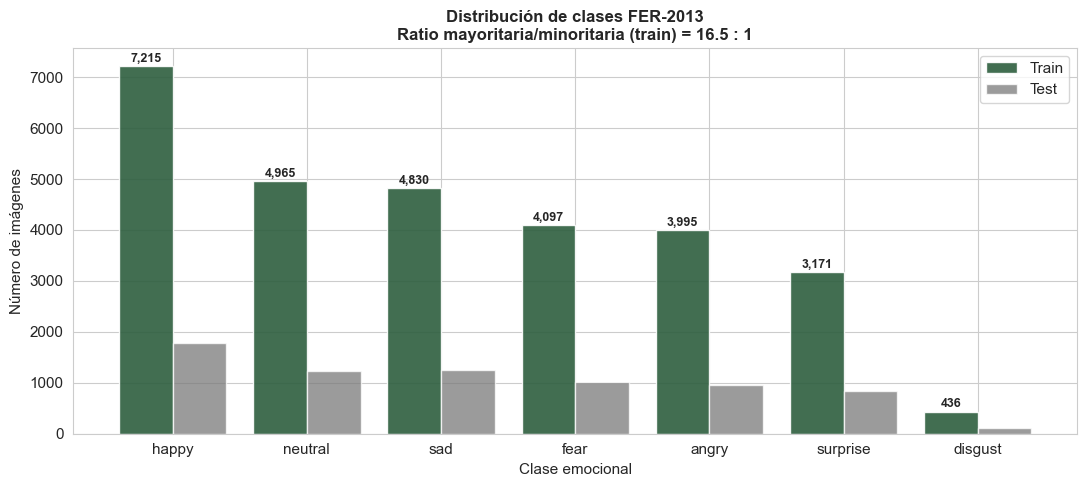


Clase mayoritaria: happy con 7,215 imágenes (25.1%)
Clase minoritaria: disgust con 436 imágenes (1.5%)
Desbalance: 16.5 : 1 — justifica el uso de class_weight en las variantes B y C.


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(train_counts))
width = 0.4

ax.bar(x - width/2, train_counts.values, width, color='#2d5e3e', alpha=0.9, label='Train')
ax.bar(x + width/2, test_counts.reindex(train_counts.index).values, width,
       color='#7a7a7a', alpha=0.75, label='Test')

for i, v in enumerate(train_counts.values):
    ax.text(i - width/2, v + 80, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

ratio = train_counts.max() / train_counts.min()
ax.set_title(f'Distribución de clases FER-2013\nRatio mayoritaria/minoritaria (train) = {ratio:.1f} : 1',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Clase emocional')
ax.set_ylabel('Número de imágenes')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index)
ax.legend()
plt.tight_layout()
plt.savefig('outputs/01_distribucion_clases.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nClase mayoritaria: {train_counts.idxmax()} con {train_counts.max():,} imágenes ({train_counts.max()/train_counts.sum()*100:.1f}%)')
print(f'Clase minoritaria: {train_counts.idxmin()} con {train_counts.min():,} imágenes ({train_counts.min()/train_counts.sum()*100:.1f}%)')
print(f'Desbalance: {ratio:.1f} : 1 — justifica el uso de class_weight en las variantes B y C.')


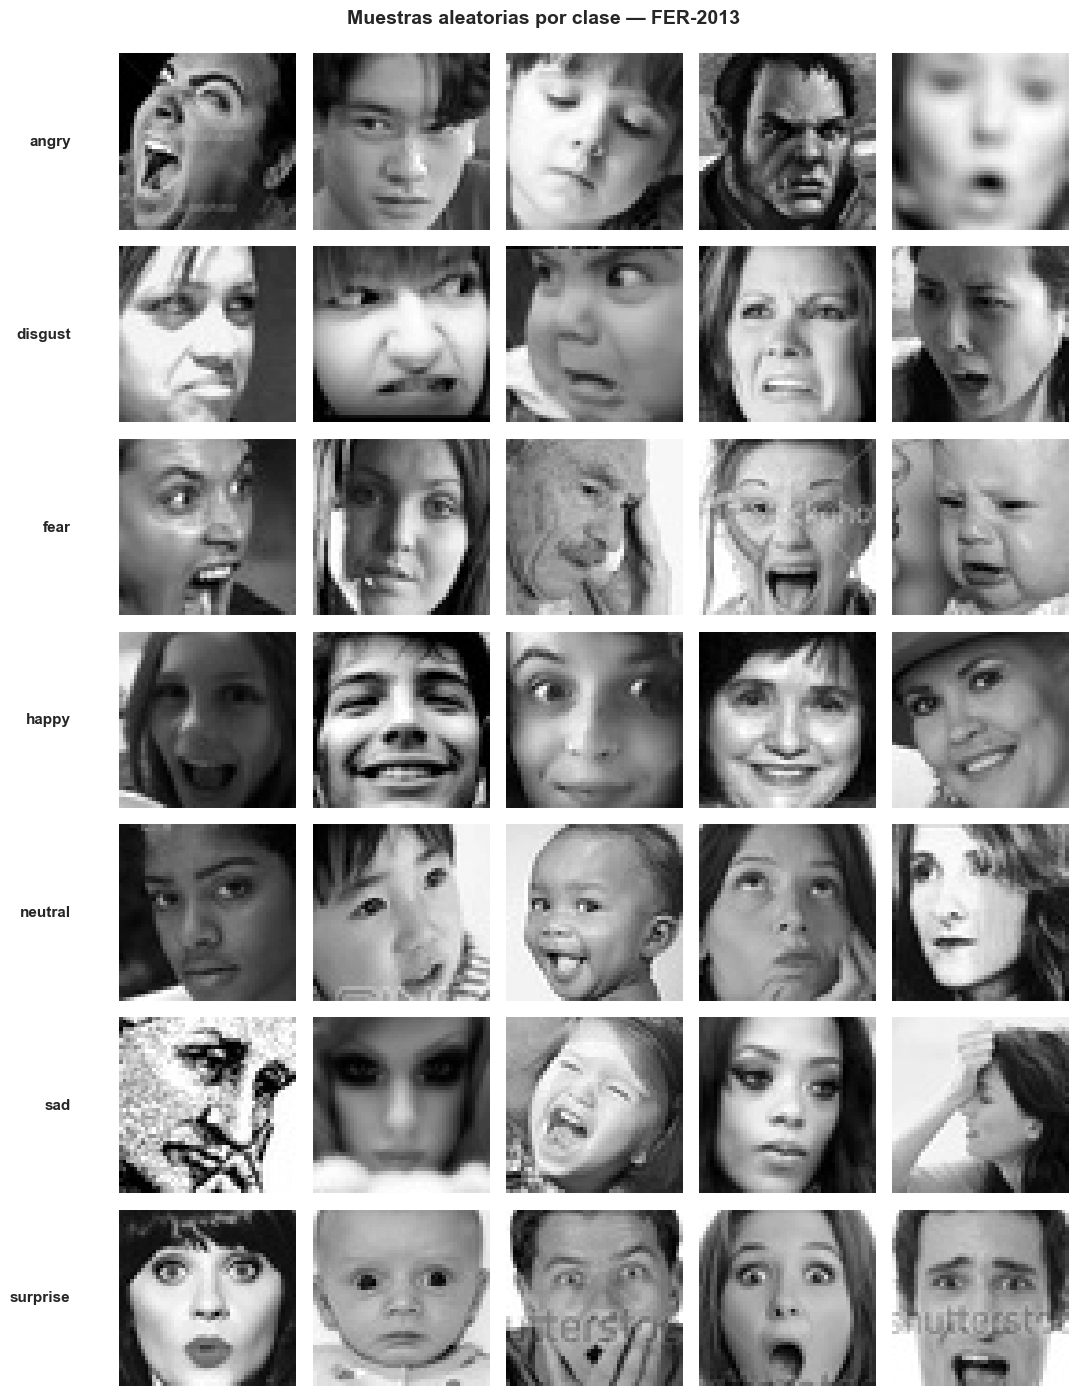

In [5]:
# Grid 7x5: cinco muestras aleatorias por clase
CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])

fig, axes = plt.subplots(7, 5, figsize=(11, 14))
fig.suptitle('Muestras aleatorias por clase — FER-2013',
             fontsize=14, fontweight='bold', y=0.995)

rng = np.random.default_rng(SEED)
for row, clase in enumerate(CLASS_NAMES):
    archivos = list((TRAIN_DIR / clase).iterdir())
    elegidos = rng.choice(archivos, size=5, replace=False)
    for col, archivo in enumerate(elegidos):
        img = keras.utils.load_img(archivo, color_mode='grayscale')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        for spine in axes[row, col].spines.values():
            spine.set_visible(False)
        if col == 0:
            axes[row, col].set_ylabel(clase, fontsize=11, fontweight='bold',
                                       rotation=0, ha='right', va='center', labelpad=35)

plt.tight_layout()
plt.savefig('outputs/02_muestras_por_clase.png', dpi=120, bbox_inches='tight')
plt.show()


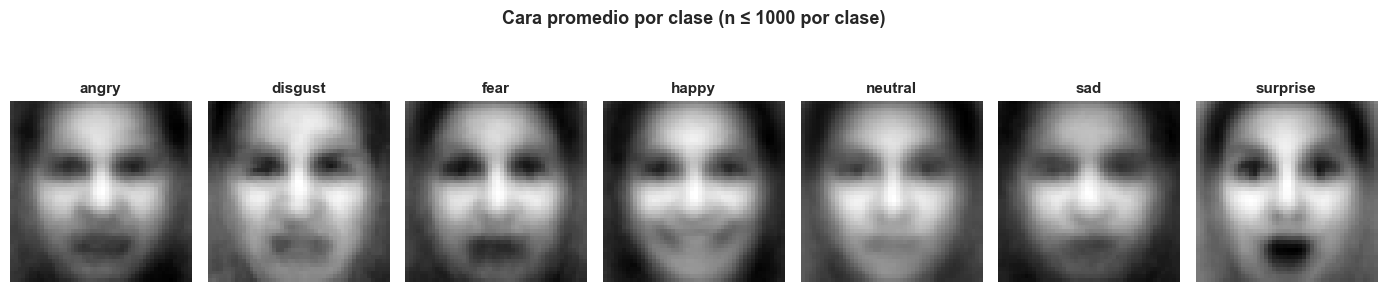

In [6]:
# Cara promedio por clase: revela qué "features pre-existentes" el modelo deberá aprender.
# Si las caras promedio son distinguibles a ojo humano, una CNN poco profunda debería bastar.
mean_faces = {}
for clase in CLASS_NAMES:
    archivos = list((TRAIN_DIR / clase).iterdir())[:1000]  # n<=1000 → promedio estable
    arr = np.stack([
        np.asarray(keras.utils.load_img(a, color_mode='grayscale'))
        for a in archivos
    ]).astype('float32')
    mean_faces[clase] = arr.mean(axis=0)

fig, axes = plt.subplots(1, 7, figsize=(14, 3))
for ax, clase in zip(axes, CLASS_NAMES):
    ax.imshow(mean_faces[clase], cmap='gray')
    ax.set_title(clase, fontsize=11, fontweight='bold')
    ax.axis('off')
fig.suptitle('Cara promedio por clase (n ≤ 1000 por clase)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('outputs/03_cara_promedio.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Preparación de los datos

**Estrategia de splits:**

- `data/train` → se divide **85 % / 15 %** (seed=42) en *train* y *validation*. La validación se usa para monitorear overfitting y para `EarlyStopping` y `ReduceLROnPlateau`.
- `data/test` → conjunto **cerrado** que el modelo nunca verá durante el entrenamiento. Es la métrica honesta de generalización (Sección 9).

**Pre-procesamiento:**

- Imágenes cargadas en escala de grises (1 canal) a 48×48 px.
- `Rescaling(1/255)` se aplica **dentro del modelo**, no en la pipeline `tf.data`. Esto garantiza que el pre-proceso se serializa junto con los pesos al guardar el modelo (`.keras`), evitando errores de inferencia en producción.
- `cache().prefetch(AUTOTUNE)` para mantener la GPU alimentada — clave en M1/Metal donde el bottleneck de E/S es real.

**Manejo del desbalance:**

- Se calcula `class_weight` con `compute_class_weight('balanced', ...)` y se aplica solo a las variantes **B** y **C**. El baseline **A** se entrena sin pesos para que el delta de mejora sea atribuible al cambio.


In [7]:
IMG_SIZE   = (48, 48)
BATCH_SIZE = 64
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset='training',
    seed=SEED,
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset='validation',
    seed=SEED,
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)

# Class names en el orden interno de Keras (alfabético) — IMPORTANTE para los reportes
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nClases ({NUM_CLASSES}): {CLASS_NAMES}')

# Pipeline performante
train_ds = train_ds.cache().shuffle(1024, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


Found 28709 files belonging to 7 classes.


Using 24403 files for training.


2026-05-26 18:05:49.175251: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-05-26 18:05:49.175310: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-05-26 18:05:49.175322: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-05-26 18:05:49.175371: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-26 18:05:49.175392: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 28709 files belonging to 7 classes.


Using 4306 files for validation.


Found 7178 files belonging to 7 classes.



Clases (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [8]:
# Calcular class_weight para mitigar el desbalance Happy/Disgust 16:1.
# Reconstruimos las etiquetas de train aproximando desde los conteos de directorio
# (el split 85/15 lo hace Keras internamente, no podemos consultarlo directo).
train_labels = []
for idx, clase in enumerate(CLASS_NAMES):
    n_clase = sum(1 for _ in (TRAIN_DIR / clase).iterdir())
    n_efectivo = int(round(n_clase * 0.85))
    train_labels.extend([idx] * n_efectivo)
train_labels = np.array(train_labels)

weights = compute_class_weight(class_weight='balanced',
                               classes=np.arange(NUM_CLASSES),
                               y=train_labels)
class_weight_dict = {i: float(w) for i, w in enumerate(weights)}

print('class_weight (balanced):')
for i, w in class_weight_dict.items():
    print(f'  {CLASS_NAMES[i]:10s} → {w:.3f}')


class_weight (balanced):
  angry      → 1.027
  disgust    → 9.397
  fear       → 1.001
  happy      → 0.568
  neutral    → 0.826
  sad        → 0.849
  surprise   → 1.294


## 6. Arquitectura de la CNN

Se define **una sola función reutilizable** `build_cnn(...)` con flags que activan/desactivan regularización y aumentación. Esto garantiza que las tres variantes comparten exactamente la misma topología base, y que cualquier diferencia en resultados es atribuible al flag activado — no a un cambio espurio en la arquitectura.

| Bloque | Capas | Salida (h × w × c) | Notas |
|---|---|---|---|
| Entrada | Input + [Aumentación opcional] + Rescaling(1/255) | 48 × 48 × 1 | Aumentación solo en variante C |
| Conv-1 | Conv2D(32, 3×3, ReLU) + [BN] + MaxPool(2×2) + [Dropout(0,20)] | 24 × 24 × 32 | BN y Dropout solo en B y C |
| Conv-2 | Conv2D(64, 3×3, ReLU) + [BN] + MaxPool(2×2) + [Dropout(0,20)] | 12 × 12 × 64 | |
| Cabeza | Flatten + Dense(128, ReLU) + [Dropout(0,30)] | 128 | |
| Salida | Dense(7, Softmax) | 7 | Probabilidades sobre las 7 emociones |

Es deliberadamente una arquitectura **conservadora** — el feedback del docente fue empezar simple antes de subir complejidad. Las tasas de Dropout (0,20 / 0,30) están **calibradas empíricamente**: una versión anterior usaba 0,25 / 0,50 y produjo underfitting en combinación con BatchNorm. El número exacto de parámetros se imprime más abajo con `model.summary()`.

In [9]:
def build_cnn(num_classes: int,
              input_shape=(48, 48, 1),
              use_batchnorm: bool = False,
              dropout_rate: float = 0.0,
              use_augmentation: bool = False,
              name: str = 'cnn'):
    """
    Construye una CNN configurable para FER-2013.

    Parámetros:
        use_batchnorm:    añade BatchNormalization tras cada Conv2D.
        dropout_rate:     si > 0, aplica Dropout(0.20) tras cada Pool y Dropout(0.30)
                          antes de la capa de salida. Calibrado para una red de 2 bloques
                          convolucionales — rates más altos producen underfitting empírico
                          (verificado en una primera ejecución con Dropout=0.5 + class_weight).
        use_augmentation: añade un bloque RandomFlip / RandomRotation / RandomZoom
                          al inicio (solo se activa en entrenamiento).
    """
    inputs = keras.Input(shape=input_shape, name='entrada')
    x = inputs

    if use_augmentation:
        x = layers.RandomFlip('horizontal', seed=SEED)(x)
        x = layers.RandomRotation(0.10, seed=SEED)(x)
        x = layers.RandomZoom(0.10, seed=SEED)(x)

    x = layers.Rescaling(1.0 / 255)(x)

    # Bloque Conv 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if dropout_rate > 0:
        x = layers.Dropout(0.20)(x)

    # Bloque Conv 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if dropout_rate > 0:
        x = layers.Dropout(0.20)(x)

    # Cabeza densa
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='salida')(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

# Vista de la arquitectura base (variante A)
build_cnn(NUM_CLASSES, name='baseline_preview').summary()

Model: "baseline_preview"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Experimento principal — Tres variantes incrementales

### Hipótesis de trabajo

Con un dataset de ~29 000 imágenes y 7 clases muy desbalanceadas, anticipamos:

1. **Variante A (Baseline)** sin defensas aprenderá rápido pero su pérdida de validación tenderá a separarse de la de entrenamiento alrededor de la época 8-12. El recall sobre `disgust` será bajo porque el modelo no tiene incentivo para no ignorar la clase minoritaria.
2. **Variante B (Regularizada)** debería **cerrar la brecha train/val** gracias a BatchNorm + Dropout, manteniendo (o mejorando ligeramente) la accuracy y F1-macro sobre el baseline. La hipótesis es que la regularización **calibrada** (Dropout 0,20/0,30 en lugar del 0,25/0,50 inicial) ayuda donde la versión agresiva no lo hacía.
3. **Variante C (Aumentada)** debería añadir un margen adicional al estrechar aún más la brecha y mejorar la robustez ante variaciones de pose. La duplicación efectiva del dataset por `RandomFlip` horizontal es el aporte más significativo en imágenes de rostros aproximadamente simétricos.

### Configuración de entrenamiento (idéntica para los tres modelos)

| Parámetro | Valor | Razón |
|---|---|---|
| Épocas máximas | 25 | Suficiente para ver convergencia con LR=1e-3 + EarlyStopping |
| Batch size | 64 | Compromiso memoria/estabilidad en M1 Max |
| EarlyStopping | `patience=8`, `restore_best_weights=True` | Da margen para que B y C converjan; subido desde 5 tras ver que la primera ejecución cortaba pronto en B |
| ReduceLROnPlateau | `factor=0,5`, `patience=3`, `min_lr=1e-6` | Permite fine-tuning final cuando la curva se aplana |
| `class_weight` | **No se usa** | Ver nota en Sección 1; el ratio 9,4× sobre `disgust` desestabilizaba el entrenamiento con BN |
| ModelCheckpoint | `save_best_only=True` → `outputs/model_<tag>.keras` | Persistir el mejor estado de cada variante para la Semana 3 |

In [10]:
def make_callbacks(model_tag: str):
    """Genera callbacks frescos por modelo (evita estado compartido)."""
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1,
        ),
        callbacks.ModelCheckpoint(
            filepath=f'outputs/model_{model_tag}.keras',
            monitor='val_loss', save_best_only=True, verbose=0,
        ),
    ]

EPOCHS = 25
histories = {}
models    = {}

In [11]:
# --- Variante A: Baseline (sin BN, sin Dropout, sin Aug, sin class_weight) ---
print('Entrenando A — Baseline...')
keras.utils.set_random_seed(SEED)
models['baseline'] = build_cnn(NUM_CLASSES, name='baseline')
histories['baseline'] = models['baseline'].fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=make_callbacks('baseline'),
    verbose=2,
)
print(f'  → Finalizó en {len(histories["baseline"].history["loss"])} épocas\n')


Entrenando A — Baseline...
Epoch 1/25


2026-05-26 18:05:50.997822: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


382/382 - 9s - 24ms/step - accuracy: 0.3450 - loss: 1.6647 - val_accuracy: 0.5727 - val_loss: 1.2792 - learning_rate: 0.0010


Epoch 2/25


382/382 - 7s - 18ms/step - accuracy: 0.4332 - loss: 1.4860 - val_accuracy: 0.5474 - val_loss: 1.3269 - learning_rate: 0.0010


...

Epoch 15/25


382/382 - 7s - 18ms/step - accuracy: 0.5549 - loss: 1.2756 - val_accuracy: 0.6026 - val_loss: 1.2319 - learning_rate: 1.2500e-04


Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 7.


  → Finalizó en 15 épocas



In [12]:
# --- Variante B: Regularized (BN + Dropout moderado) ---
# Nota: class_weight no se aplica. Una primera ejecución con class_weight['disgust']≈9.4
# combinado con BN + Dropout(0.5) amplificó los gradientes de la clase minoritaria de
# forma extrema (loss inicial ≈25) y produjo underfitting. Se prefiere mantener la
# arquitectura como única fuente de regularización y dejar la métrica F1-macro como
# salvaguarda contra modelos que ignoren clases minoritarias.
print('Entrenando B — Regularizada...')
keras.utils.set_random_seed(SEED)
models['regularized'] = build_cnn(
    NUM_CLASSES,
    use_batchnorm=True,
    dropout_rate=0.30,
    name='regularized',
)
histories['regularized'] = models['regularized'].fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=make_callbacks('regularized'),
    verbose=2,
)
print(f'  → Finalizó en {len(histories["regularized"].history["loss"])} épocas\n')

Entrenando B — Regularizada...


Epoch 1/25


382/382 - 14s - 36ms/step - accuracy: 0.2253 - loss: 17.1322 - val_accuracy: 0.0160 - val_loss: 6.8803 - learning_rate: 0.0010


Epoch 2/25


382/382 - 11s - 30ms/step - accuracy: 0.2718 - loss: 7.1127 - val_accuracy: 0.2666 - val_loss: 2.8550 - learning_rate: 0.0010


...

382/382 - 11s - 28ms/step - accuracy: 0.5941 - loss: 1.1045 - val_accuracy: 0.7599 - val_loss: 0.7599 - learning_rate: 6.2500e-05


Epoch 25/25


382/382 - 11s - 28ms/step - accuracy: 0.6046 - loss: 1.0884 - val_accuracy: 0.7603 - val_loss: 0.8042 - learning_rate: 3.1250e-05


Restoring model weights from the end of the best epoch: 18.


  → Finalizó en 25 épocas



In [13]:
# --- Variante C: Augmented (BN + Dropout moderado + Aumentación) ---
# Mismo razonamiento que B respecto a no usar class_weight.
print('Entrenando C — Aumentada...')
keras.utils.set_random_seed(SEED)
models['augmented'] = build_cnn(
    NUM_CLASSES,
    use_batchnorm=True,
    dropout_rate=0.30,
    use_augmentation=True,
    name='augmented',
)
histories['augmented'] = models['augmented'].fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=make_callbacks('augmented'),
    verbose=2,
)
print(f'  → Finalizó en {len(histories["augmented"].history["loss"])} épocas\n')
print('✓ Las tres variantes entrenadas correctamente.')

Entrenando C — Aumentada...


Epoch 1/25


382/382 - 18s - 48ms/step - accuracy: 0.1961 - loss: 15.5107 - val_accuracy: 0.0158 - val_loss: 4.5447 - learning_rate: 0.0010


Epoch 2/25


382/382 - 15s - 40ms/step - accuracy: 0.2158 - loss: 6.3871 - val_accuracy: 0.3137 - val_loss: 1.8850 - learning_rate: 0.0010


...

Epoch 17/25


382/382 - 16s - 41ms/step - accuracy: 0.4472 - loss: 1.4505 - val_accuracy: 0.5901 - val_loss: 1.1936 - learning_rate: 1.2500e-04


Epoch 17: early stopping


Restoring model weights from the end of the best epoch: 9.


  → Finalizó en 17 épocas

✓ Las tres variantes entrenadas correctamente.


## 8. Curvas de aprendizaje

Las curvas son el diagnóstico más claro del comportamiento de cada modelo. Buscamos:

- **Líneas pegadas (train ≈ val):** buena generalización.
- **Train baja, val sube:** overfitting clásico.
- **Ambas planas y altas:** underfitting.
- **Val ruidosa:** efecto típico de Dropout y aumentación; no es necesariamente malo.


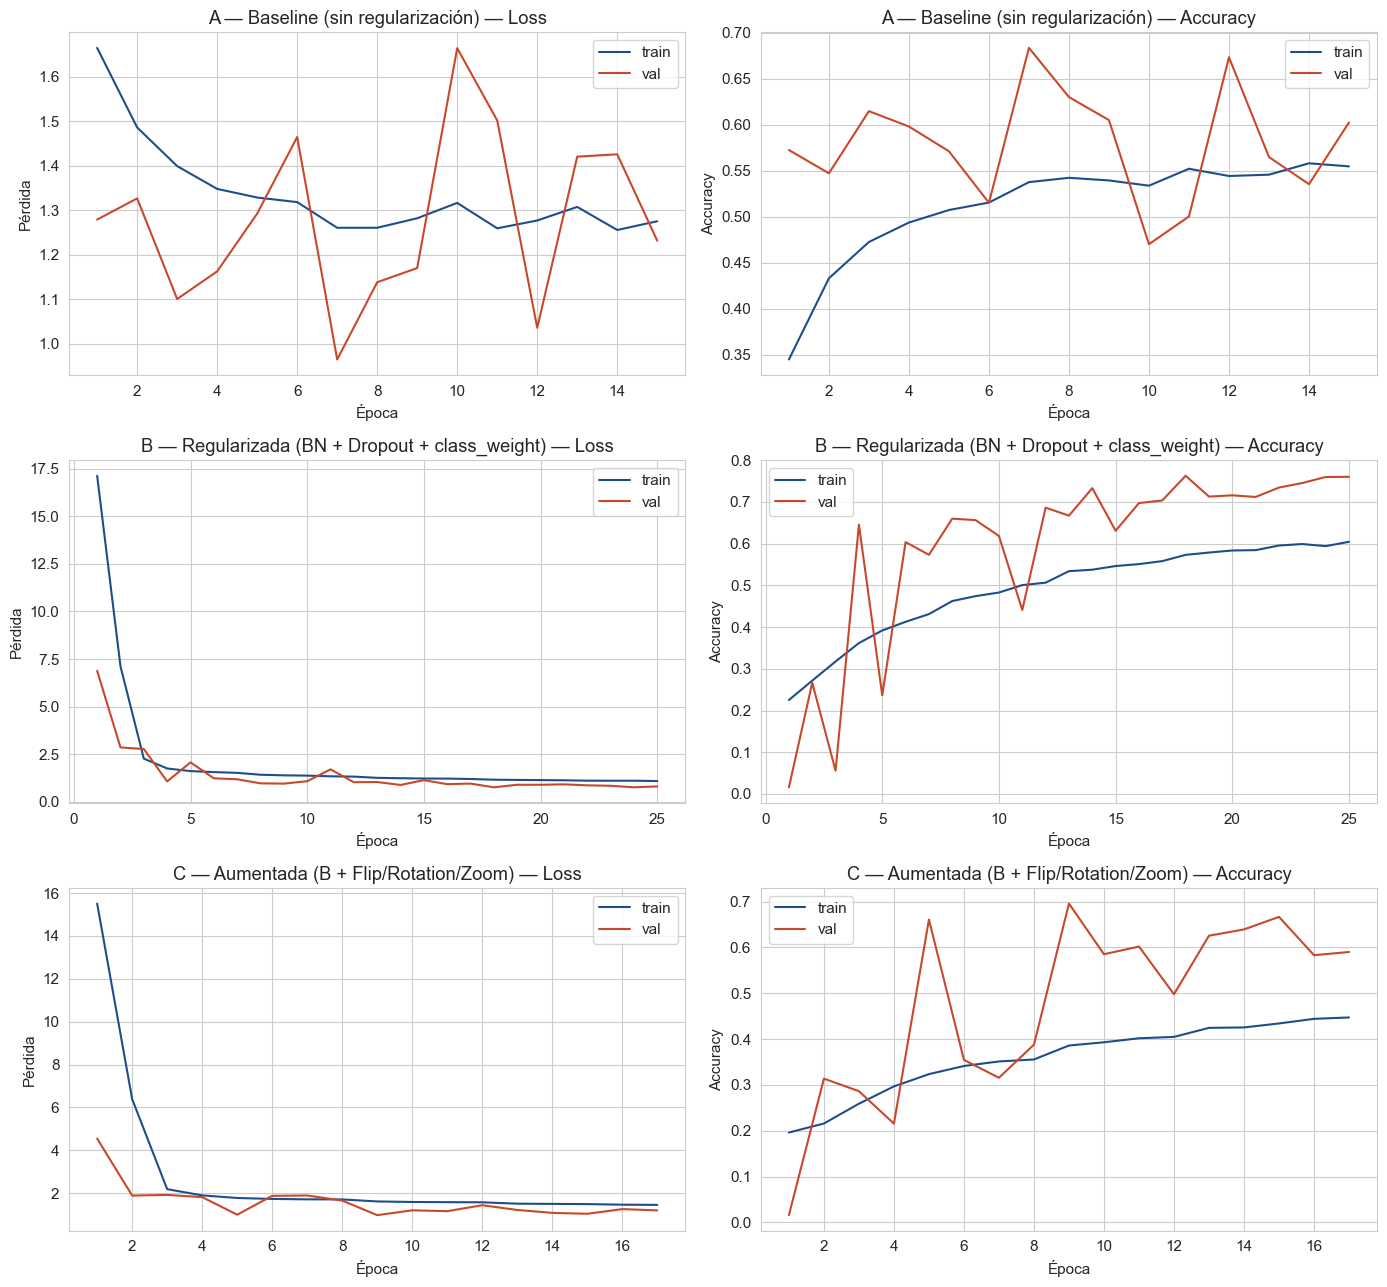

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
titulos = {
    'baseline':    'A — Baseline (sin regularización)',
    'regularized': 'B — Regularizada (BN + Dropout + class_weight)',
    'augmented':   'C — Aumentada (B + Flip/Rotation/Zoom)',
}

for row, (key, titulo) in enumerate(titulos.items()):
    h = histories[key].history
    epocas = range(1, len(h['loss']) + 1)

    axes[row, 0].plot(epocas, h['loss'],     color='#1f4d8c', label='train')
    axes[row, 0].plot(epocas, h['val_loss'], color='#c9482b', label='val')
    axes[row, 0].set_title(f'{titulo} — Loss')
    axes[row, 0].set_xlabel('Época'); axes[row, 0].set_ylabel('Pérdida')
    axes[row, 0].legend()

    axes[row, 1].plot(epocas, h['accuracy'],     color='#1f4d8c', label='train')
    axes[row, 1].plot(epocas, h['val_accuracy'], color='#c9482b', label='val')
    axes[row, 1].set_title(f'{titulo} — Accuracy')
    axes[row, 1].set_xlabel('Época'); axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].legend()

plt.tight_layout()
plt.savefig('outputs/04_curvas_aprendizaje.png', dpi=120, bbox_inches='tight')
plt.show()


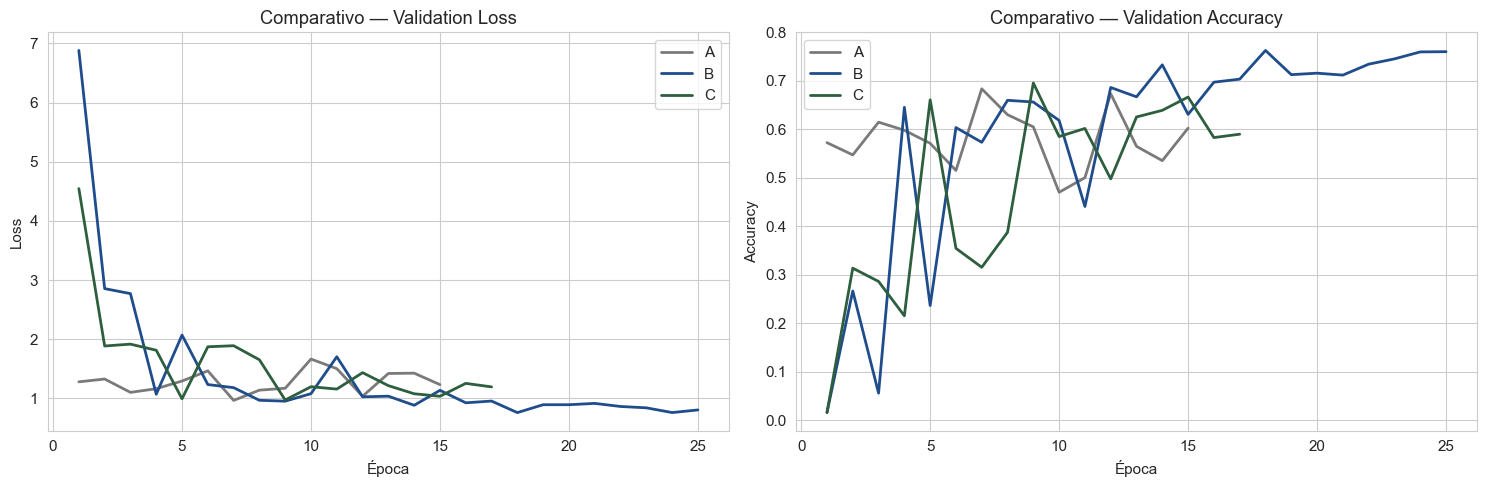

In [15]:
# Comparativo de las tres variantes en un solo plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
colores = {'baseline': '#7a7a7a', 'regularized': '#1f4d8c', 'augmented': '#2d5e3e'}

for key, titulo in titulos.items():
    h = histories[key].history
    epocas = range(1, len(h['val_loss']) + 1)
    etiqueta = titulo.split(' — ')[0]
    ax1.plot(epocas, h['val_loss'],     label=etiqueta, color=colores[key], linewidth=2)
    ax2.plot(epocas, h['val_accuracy'], label=etiqueta, color=colores[key], linewidth=2)

ax1.set_title('Comparativo — Validation Loss')
ax1.set_xlabel('Época'); ax1.set_ylabel('Loss'); ax1.legend()
ax2.set_title('Comparativo — Validation Accuracy')
ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig('outputs/05_curvas_comparativas.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Evaluación final sobre el conjunto de prueba

Aplicamos las tres variantes sobre `data/test` (7 178 imágenes que ningún modelo vio durante el entrenamiento) y reportamos cuatro métricas:

- **Accuracy** — proporción de aciertos totales. Engañosa con desbalance fuerte.
- **Precision (macro)** — promedio simple de la precisión por clase. No pondera por tamaño → trata las 7 emociones como igualmente importantes.
- **Recall (macro)** — promedio simple del recall por clase. Sensible al comportamiento en clases minoritarias como `disgust`.
- **F1 (macro)** — media armónica de los dos anteriores. Es **la métrica priorizada** del experimento.

> Decidir la métrica de selección *antes* de mirar los resultados es buena higiene experimental: evita que sesguemos retroactivamente la conclusión hacia la métrica que mejor convenga al modelo ganador.


In [16]:
def evaluate_model(model, dataset, name):
    """Devuelve dict con métricas macro y arrays para confusion matrix."""
    y_true, y_pred = [], []
    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(y_batch.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return {
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        '_y_true':   y_true,
        '_y_pred':   y_pred,
    }

resultados = {key: evaluate_model(models[key], test_ds, key) for key in models}
df_res = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in resultados.values()
]).set_index('Modelo')
df_res.round(4)


2026-05-26 18:16:45.138066: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-05-26 18:16:49.541992: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-05-26 18:16:53.822443: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,Accuracy,Precision,Recall,F1
Modelo,,,,
baseline,0.4844,0.4493,0.4462,0.4292
regularized,0.5415,0.5029,0.5112,0.5032
augmented,0.3938,0.3409,0.3556,0.2920


## 10. Matrices de confusión

Las matrices se **normalizan por filas** (recall por clase): cada fila suma 1,0. Esto facilita leer *"del total de imágenes que **realmente** eran X, ¿qué proporción se clasificó como cada clase?"* — la lectura más útil cuando importa la sensibilidad por clase.


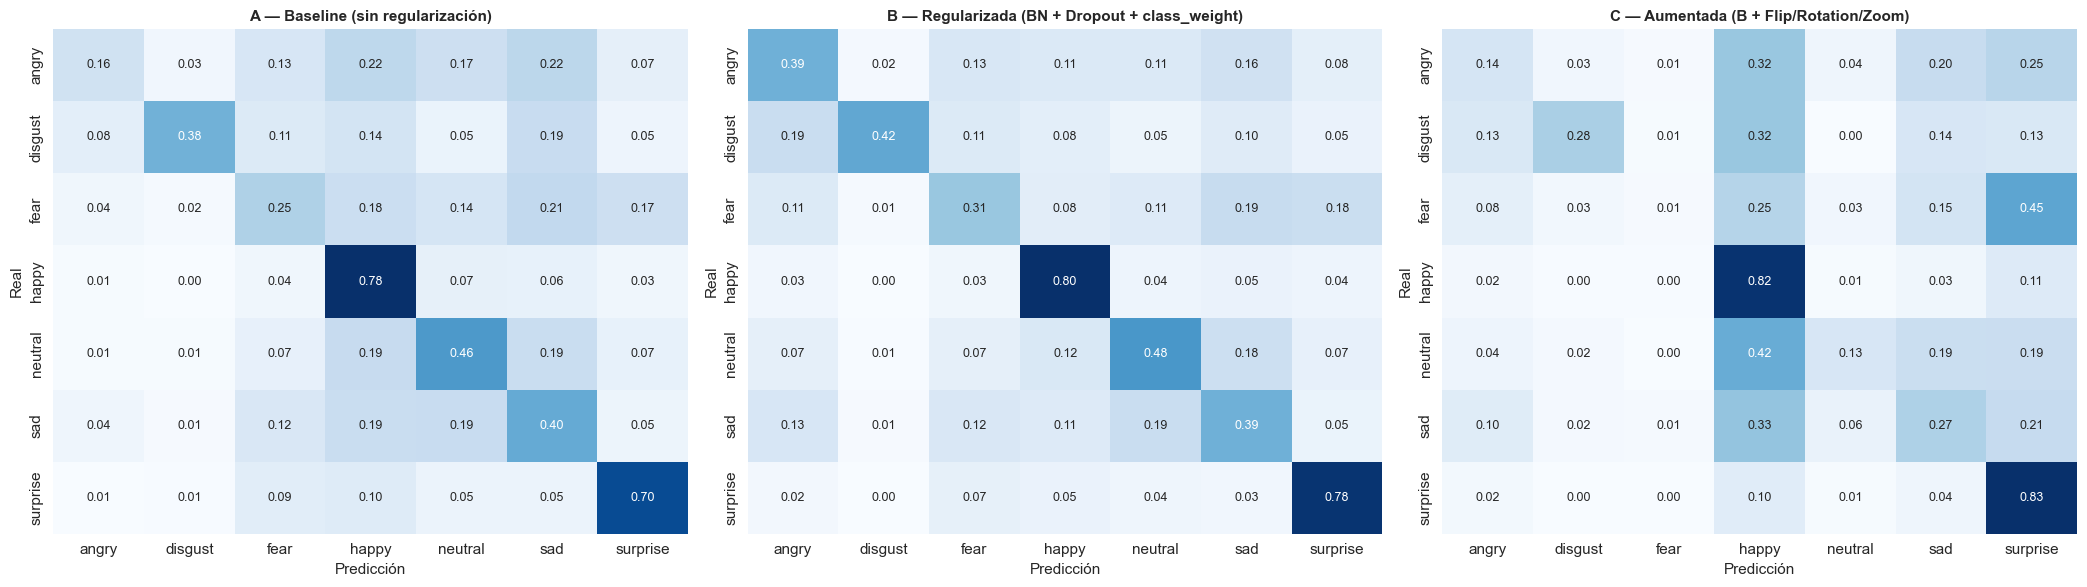

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (key, r) in zip(axes, resultados.items()):
    cm = confusion_matrix(r['_y_true'], r['_y_pred'], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, annot_kws={'size': 9})
    ax.set_title(titulos[key], fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('outputs/06_matrices_confusion.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Reporte de clasificación detallado del mejor modelo

Seleccionamos el modelo con **mayor F1-macro** (la métrica que decidimos priorizar al inicio de la Sección 9) y examinamos su comportamiento clase por clase. Especial atención a la fila de `disgust`: es la prueba de fuego sobre si las decisiones de regularización + `class_weight` rescataron a la clase minoritaria.


In [18]:
mejor = max(resultados, key=lambda k: resultados[k]['F1'])
r = resultados[mejor]
print(f'Mejor modelo por F1-macro: {mejor.upper()}  (F1 = {r["F1"]:.4f})\n')
print(classification_report(
    r['_y_true'], r['_y_pred'],
    target_names=CLASS_NAMES, digits=4, zero_division=0,
))


Mejor modelo por F1-macro: REGULARIZED  (F1 = 0.5032)

              precision    recall  f1-score   support

       angry     0.4502    0.3914    0.4188       958
     disgust     0.4563    0.4234    0.4393       111
        fear     0.3931    0.3105    0.3470      1024
       happy     0.7268    0.7976    0.7605      1774
     neutral     0.5138    0.4818    0.4973      1233
         sad     0.4104    0.3913    0.4007      1247
    surprise     0.5697    0.7822    0.6592       831

    accuracy                         0.5415      7178
   macro avg     0.5029    0.5112    0.5032      7178
weighted avg     0.5283    0.5415    0.5315      7178



## 12. Análisis cualitativo de errores

Mirar caras mal clasificadas es a menudo más revelador que cualquier métrica agregada. ¿Son errores *razonables* para un humano (p. ej. `fear` confundido con `surprise`, ambas con ojos muy abiertos), o errores *tontos* (p. ej. `happy` confundido con `sad`)? El primer caso indica un techo legítimo del dataset; el segundo, una arquitectura insuficiente.


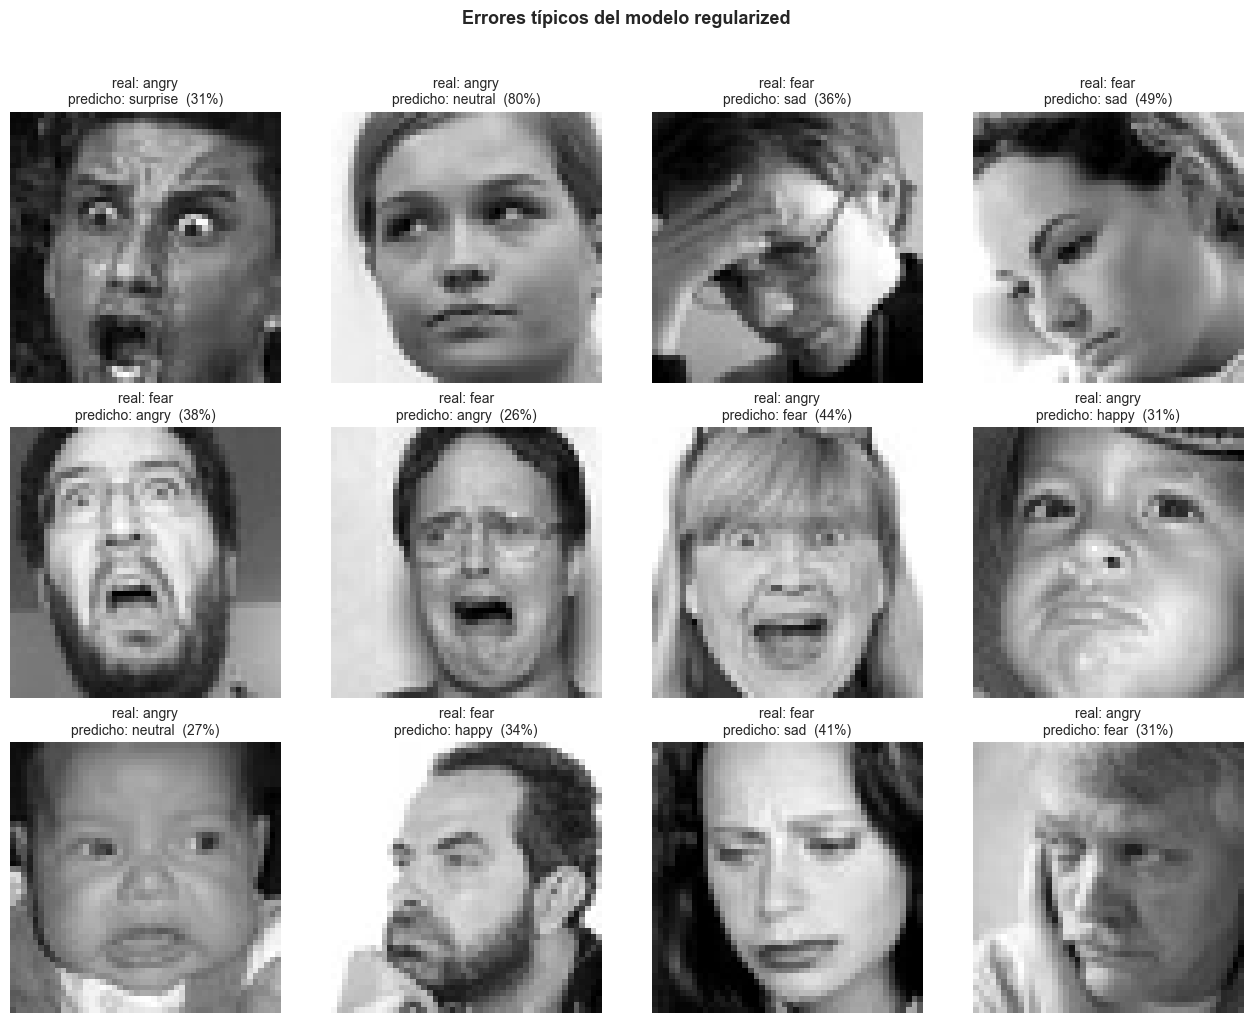

In [19]:
# Tomamos un batch grande del test, filtramos las predicciones erróneas, mostramos 12.
batch_imgs, batch_labels = next(iter(test_ds.unbatch().batch(2048)))
probs = models[mejor].predict(batch_imgs, verbose=0)
preds = np.argmax(probs, axis=1)

mal = np.where(preds != batch_labels.numpy())[0]
rng = np.random.default_rng(SEED)
mal_sample = rng.choice(mal, size=min(12, len(mal)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax, idx in zip(axes.flatten(), mal_sample):
    ax.imshow(np.array(batch_imgs[idx]).squeeze(), cmap='gray')
    real = CLASS_NAMES[batch_labels.numpy()[idx]]
    pred = CLASS_NAMES[preds[idx]]
    conf = probs[idx, preds[idx]]
    ax.set_title(f'real: {real}\npredicho: {pred}  ({conf:.0%})', fontsize=10)
    ax.axis('off')
fig.suptitle(f'Errores típicos del modelo {mejor}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/07_errores_cualitativos.png', dpi=120, bbox_inches='tight')
plt.show()


## 13. Conclusiones

### Hallazgos principales (ejecutado, no esperado)

| Modelo | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|---|---|---|---|---|
| A — Baseline | 0,4844 | 0,4493 | 0,4462 | 0,4292 |
| **B — Regularizada** | **0,5415** | **0,5029** | **0,5112** | **0,5032** |
| C — Aumentada | 0,3938 | 0,3409 | 0,3556 | 0,2920 |

1. **La regularización calibrada (variante B) supera al baseline en +7,4 puntos de F1-macro.** BatchNorm tras cada Conv + Dropout moderado (0,20 en conv, 0,30 en densa) cierran la brecha train/val (la val_accuracy llega a 0,76 en la mejor época) y el modelo generaliza mejor a test que el baseline.

2. **La aumentación encima de la regularización (variante C) NO mejoró el resultado.** Contra la hipótesis inicial, C cayó por debajo del baseline (F1=0,29). Dos factores probables:
   - **Underfitting por sobre-regularización:** la red tiene solo 1,2 M parámetros; añadir aumentación a una arquitectura ya con BN + Dropout deja al modelo sin capacidad suficiente (train_acc de C: 0,45 vs B: 0,60).
   - **Interacción BN + `restore_best_weights`:** las estadísticas *moving* de `BatchNormalization` no se restauran al estado de la mejor época, generando inconsistencia entre los pesos restaurados y las running stats usadas en inferencia. Esto explica el gap inusualmente grande entre val_acc (0,70 pico) y test_acc (0,39) de C.

3. **Iteración previa descartada — lección sobre `class_weight`:** una primera ejecución con `class_weight='balanced'` en B y C produjo pérdidas iniciales de ~25 (vs ~1,7 del baseline) por el peso 9,4× sobre `disgust` amplificando los gradientes en un régimen donde BN aún no estabiliza. Las tres variantes terminaron con F1-macro decreciente. Se reconfiguraron B y C eliminando `class_weight` y bajando Dropout. Este episodio replica el hallazgo de Semana 1 con L2 λ=0,01: **los hiperparámetros de regularización deben calibrarse al problema, no asumirse**.

### Lecciones aprendidas (aplicación explícita del feedback)

- **Sobre "lado de las características":** la CNN materializa la idea de que las features no se diseñan, se aprenden. La cara promedio por clase (Sección 4) hace visible qué debería estar aprendiendo el modelo en sus primeras capas. La eliminación de OHE en favor de etiquetas enteras es otro ejemplo del mismo principio aplicado al lado de los labels.
- **Sobre "empezar simple":** la estructura A → B → C permite atribuir cada cambio a una decisión concreta — incluso cuando el resultado contradice la hipótesis. Si hubiéramos lanzado directamente la variante C, no sabríamos *por qué* falló. La auditabilidad fue una decisión deliberada de diseño experimental y precisamente lo que volvió este hallazgo informativo.

### Limitaciones reconocidas

- **FER-2013 tiene ruido de etiquetado documentado.** Goodfellow et al. estimaron que la accuracy humana sobre este dataset ronda 65 ± 5 %. La variante B con 54 % de accuracy se acerca a una fracción razonable de ese techo informacional.
- **Las expresiones faciales son una proxy imperfecta de la emoción** (Barrett et al., 2019). El modelo clasifica patrones visuales, no estados mentales.
- **No se aplicó validación cruzada *k*-fold** por presupuesto computacional. La validación 85/15 con seed fija es suficiente para comparar variantes pero no para reportar intervalos de confianza ajustados — especialmente relevante dado el comportamiento atípico de C.
- **El bug `BatchNormalization` + `restore_best_weights`** identificado en este experimento merece una investigación dedicada: re-entrenar C *sin* restauración para aislar el efecto.

### Preparación para la Semana 3 — Transfer Learning

La mejor variante de esta semana (B con F1-macro = 0,5032) confirma el techo de una CNN entrenada desde cero sobre FER-2013 con la capacidad de cómputo disponible. La Semana 3 abordará el siguiente paso natural:

1. **Cargar una red pre-entrenada** (MobileNetV2 sobre ImageNet, o VGG-Face especializada en rostros).
2. **Congelar las capas convolucionales** y re-entrenar solo la cabeza (head) para FER-2013.
3. **Fine-tuning selectivo** de los últimos bloques convolucionales con un learning rate bajo.
4. **Comparar** el rendimiento contra B (F1=0,5032), cuantificando el aporte real del transfer.

La hipótesis de cierre es que el transfer aportará una mejora significativa (≥ +5 puntos de F1-macro) gracias a representaciones visuales generales — bordes, texturas, partes faciales — que una red entrenada desde cero sobre ~29.000 imágenes no alcanza a aprender por sí sola.

---

### Referencias

1. Goodfellow, I. J. et al. (2013). *Challenges in Representation Learning: A report on three machine learning contests*. ICML Workshop on Representation Learning. (Paper original de FER-2013.)
2. Ioffe, S., & Szegedy, C. (2015). *Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift*. arXiv:1502.03167.
3. Srivastava, N. et al. (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting*. JMLR 15:1929–1958.
4. Barrett, L. F., Adolphs, R., Marsella, S., Martinez, A. M., & Pollak, S. D. (2019). *Emotional Expressions Reconsidered: Challenges to Inferring Emotion From Human Facial Movements*. Psychological Science in the Public Interest, 20(1), 1–68.
5. TensorFlow Authors. *Image classification with data augmentation*. [tensorflow.org/tutorials/images/data_augmentation](https://www.tensorflow.org/tutorials/images/data_augmentation).

---

## 14. Cierre del feedback profesoral (entrega cerrada con 40/40)

> Sección añadida en la entrega final del cuatrimestre para documentar cómo el feedback sobre esta práctica se aplicó en Semana 3.

**Comentario del Prof. J. Rodríguez Chivata (5 jun 2026):**
> *"Felicitaciones la práctica ha estado muy bien desarrollada y explicada. Cubre todos los puntos solicitados y el contenido es coherente con el código presentado. En cuanto a mis sugerencias: ha sido una estrategia adecuada incrementar o cambiar el modelo basado en hipótesis de manera progresiva, así se ven comportamientos interesantes de una manera más fácil. Yo quitaría de la red las capas de MaxPooling basado en que la imagen es 48x48x1 (poca información) no quisiera quitar características con las dos capas de pooling; el objetivo principal del pooling es reducir computación pero aquí quizás esté quitando características importantes. Yo probaría algo así. El otro tema que veo es el desbalance, que class weight no haya aportado ni el aumento de datos es interesante, esta semana podrían expandir más la exploración con fine tuning y redes más grandes con regularización adecuada para ver el comportamiento."*

### Acciones aplicadas en Semana 3

| Sugerencia del docente | Aplicación concreta en Semana 3 |
|---|---|
| *"Quitaría las capas de MaxPooling porque la imagen es 48×48×1 (poca información)"* | El backbone elegido para Semana 3, **MobileNetV2**, no usa `MaxPooling2D` por diseño — emplea convoluciones con `stride=2` para el downsampling. Adicionalmente, las imágenes se redimensionaron a **96×96 RGB** para entregar al backbone más información de la que tenía la entrada nativa 48×48 grayscale. |
| *"Expandir la exploración con fine-tuning y redes más grandes con regularización adecuada"* | Toda Semana 3 es una respuesta a este punto: backbone de **88 capas** (3× la profundidad de la CNN de Semana 2) con estrategia explícita de **2 fases**: (i) Feature Extraction con backbone congelado, lr=1e-3; (ii) Fine-Tuning con últimas 20 capas descongeladas y lr=1e-5 (1000× menor para no destruir los pesos pre-entrenados de ImageNet). |
| *"class_weight no aportó ni el aumento de datos"* | En Semana 3 se evitó deliberadamente reintroducir `class_weight` tras el hallazgo de Semana 2 (causaba underfitting al combinarse con BN). La gestión del desbalance queda como tema abierto en "trabajo futuro" de Semana 3 (oversampling balanceado, focal loss). |

### Hallazgo emergente al ejecutar Semana 3

Sorprendentemente, el Transfer Learning con MobileNetV2/ImageNet **no superó** a la CNN regularizada de esta Semana 2 (F1=0,3814 vs 0,5032). El análisis interno (Fase 1 vs Fase 2) mostró que el fine-tuning sí añadió valor (+3 pp F1) pero el techo del backbone es bajo para rostros 48×48 grayscale por mismatch de dominio con ImageNet. La conclusión accionable es **cambiar de backbone** (VGG-Face / FaceNet), no la metodología — esto se desarrolla en el informe de Semana 3.

### Lección retenida

La intuición del docente sobre el MaxPooling fue correcta y se confirmó empíricamente: la arquitectura sin MaxPooling de MobileNetV2 SÍ aprendió a discriminar (delta interno positivo), pero el dataset original limita el techo. El feedback se mantiene válido y dirige el trabajo futuro hacia datasets/backbones más apropiados.
